In [9]:
# Cell 1 (GPU version): Device setup
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [1]:
# ============================================================
# HARDWARE MONITORING
# ============================================================

!pip install -q psutil nvidia-ml-py


import os
import time
import threading
import numpy as np
import pandas as pd
import psutil



In [2]:
# ------------------------------------------------------------
# NVIDIA NVML
# ------------------------------------------------------------

try:
    import pynvml

    pynvml.nvmlInit()
    NVML_AVAILABLE = True

except Exception:
    NVML_AVAILABLE = False

In [3]:
# ------------------------------------------------------------
# Hardware Monitor
# ------------------------------------------------------------

class HardwareMonitor:

    def __init__(self, interval=0.2, gpu_index=0):

        self.interval = interval
        self.gpu_index = gpu_index

        self.running = False
        self.thread = None

        # CPU
        self.cpu_util_samples = []
        self.ram_samples = []

        # GPU
        self.gpu_util_samples = []
        self.gpu_mem_util_samples = []
        self.vram_samples = []
        self.gpu_power_samples = []
        self.gpu_temp_samples = []

        self.timestamps = []

        self.process = psutil.Process(os.getpid())

        self.gpu_handle = None

        if NVML_AVAILABLE:

            try:
                self.gpu_handle = (
                    pynvml.nvmlDeviceGetHandleByIndex(
                        gpu_index
                    )
                )

            except Exception:
                self.gpu_handle = None

    # --------------------------------------------------------
    # Start
    # --------------------------------------------------------
    def start(self):

        # Initialize process CPU counter
        self.process.cpu_percent(None)

        self.running = True

        self.thread = threading.Thread(
            target=self._monitor,
            daemon=True
        )

        self.thread.start()

    # --------------------------------------------------------
    # Monitoring loop
    # --------------------------------------------------------
    def _monitor(self):

        logical_cpus = psutil.cpu_count(
            logical=True
        )

        while self.running:

            timestamp = time.perf_counter()
            # =================================================
            # CPU UTILIZATION
            # =================================================
            process_cpu = (
                self.process.cpu_percent(
                    interval=None
                )
            )

            # Normalize process CPU usage to
            # percentage of total logical CPU capacity.
            if logical_cpus:
                process_cpu_normalized = (
                    process_cpu / logical_cpus
                )
            else:
                process_cpu_normalized = process_cpu
            self.cpu_util_samples.append(
                process_cpu_normalized
            )

            # =================================================
            # RAM
            # =================================================

            ram_mb = (
                self.process.memory_info().rss
                / (1024 ** 2)
            )

            self.ram_samples.append(
                ram_mb
            )

            # =================================================
            # GPU
            # =================================================

            if self.gpu_handle is not None:

                try:

                    utilization = (
                        pynvml.nvmlDeviceGetUtilizationRates(
                            self.gpu_handle
                        )
                    )

                    memory = (
                        pynvml.nvmlDeviceGetMemoryInfo(
                            self.gpu_handle
                        )
                    )

                    power = (
                        pynvml.nvmlDeviceGetPowerUsage(
                            self.gpu_handle
                        ) / 1000.0
                    )

                    temperature = (
                        pynvml.nvmlDeviceGetTemperature(
                            self.gpu_handle,
                            pynvml.NVML_TEMPERATURE_GPU
                        )
                    )

                    # GPU compute utilization
                    self.gpu_util_samples.append(
                        float(utilization.gpu)
                    )

                    # GPU memory-controller utilization
                    self.gpu_mem_util_samples.append(
                        float(utilization.memory)
                    )

                    # VRAM used
                    self.vram_samples.append(
                        memory.used / (1024 ** 2)
                    )

                    # Power in Watts
                    self.gpu_power_samples.append(
                        power
                    )

                    # Temperature
                    self.gpu_temp_samples.append(
                        float(temperature)
                    )

                except Exception:
                    pass

            self.timestamps.append(
                timestamp
            )

            time.sleep(
                self.interval
            )

    # --------------------------------------------------------
    # Stop
    # --------------------------------------------------------

    def stop(self):

        self.running = False

        if self.thread is not None:
            self.thread.join()

    # --------------------------------------------------------
    # Results
    # --------------------------------------------------------

    def get_results(self):

        result = {}

        # =====================================================
        # CPU
        # =====================================================

        result["avg_cpu_util_percent"] = (
            np.mean(
                self.cpu_util_samples
            )
            if self.cpu_util_samples
            else np.nan
        )

        result["peak_cpu_util_percent"] = (
            np.max(
                self.cpu_util_samples
            )
            if self.cpu_util_samples
            else np.nan
        )

        result["avg_ram_mb"] = (
            np.mean(
                self.ram_samples
            )
            if self.ram_samples
            else np.nan
        )

        result["peak_ram_mb"] = (
            np.max(
                self.ram_samples
            )
            if self.ram_samples
            else np.nan
        )

        # =====================================================
        # GPU
        # =====================================================

        if self.gpu_util_samples:

            result["avg_gpu_util_percent"] = np.mean(
                self.gpu_util_samples
            )

            result["peak_gpu_util_percent"] = np.max(
                self.gpu_util_samples
            )

            result["avg_gpu_memory_util_percent"] = np.mean(
                self.gpu_mem_util_samples
            )

            result["peak_gpu_memory_util_percent"] = np.max(
                self.gpu_mem_util_samples
            )

            result["avg_vram_mb"] = np.mean(
                self.vram_samples
            )

            result["peak_vram_mb"] = np.max(
                self.vram_samples
            )

            result["avg_gpu_power_w"] = np.mean(
                self.gpu_power_samples
            )

            result["peak_gpu_power_w"] = np.max(
                self.gpu_power_samples
            )

            result["avg_gpu_temperature_c"] = np.mean(
                self.gpu_temp_samples
            )

            result["peak_gpu_temperature_c"] = np.max(
                self.gpu_temp_samples
            )

            # =================================================
            # Energy
            # E = integral(P dt)
            # Trapezoidal approximation
            # =================================================

            energy_joules = 0.0

            n = min(
                len(self.gpu_power_samples),
                len(self.timestamps)
            )

            for i in range(1, n):

                dt = (
                    self.timestamps[i]
                    - self.timestamps[i - 1]
                )

                avg_power = (
                    self.gpu_power_samples[i]
                    + self.gpu_power_samples[i - 1]
                ) / 2.0

                energy_joules += (
                    avg_power * dt
                )

            result["gpu_energy_joules"] = (
                energy_joules
            )

        else:

            result["avg_gpu_util_percent"] = np.nan
            result["peak_gpu_util_percent"] = np.nan

            result["avg_gpu_memory_util_percent"] = np.nan
            result["peak_gpu_memory_util_percent"] = np.nan

            result["avg_vram_mb"] = np.nan
            result["peak_vram_mb"] = np.nan

            result["avg_gpu_power_w"] = np.nan
            result["peak_gpu_power_w"] = np.nan

            result["avg_gpu_temperature_c"] = np.nan
            result["peak_gpu_temperature_c"] = np.nan

            result["gpu_energy_joules"] = np.nan

        return result

In [4]:
# ------------------------------------------------------------
# Save 5-run results
# ------------------------------------------------------------

def save_five_run_results(
    run_results,
    filename,
    algorithm,
    device
):

    rows = []

    for result in run_results:

        row = result.copy()

        row["Algorithm"] = algorithm
        row["Device"] = device

        rows.append(row)

    runs_df = pd.DataFrame(rows)

    # --------------------------------------------------------
    # Calculate average
    # --------------------------------------------------------

    numeric_columns = [
        c for c in runs_df.columns
        if c not in ["run"]
        and pd.api.types.is_numeric_dtype(
            runs_df[c]
        )
    ]

    average_row = {
        "run": "AVERAGE",
        "Algorithm": algorithm,
        "Device": device
    }

    for column in numeric_columns:

        average_row[column] = (
            runs_df[column].mean()
        )

    # --------------------------------------------------------
    # Calculate standard deviation
    # --------------------------------------------------------

    std_row = {
        "run": "STD",
        "Algorithm": algorithm,
        "Device": device
    }

    for column in numeric_columns:

        std_row[column] = (
            runs_df[column].std()
        )

    final_df = pd.concat(
        [
            runs_df,
            pd.DataFrame([
                average_row,
                std_row
            ])
        ],
        ignore_index=True
    )

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    final_df.to_csv(
        filename,
        index=False
    )

    print("\n" + "=" * 80)
    print(f"{algorithm} - {device}")
    print("=" * 80)

    display(
        final_df.round(3)
    )

    print(
        f"\nSaved result file:\n{filename}"
    )

    return final_df

In [5]:
from google.colab import drive

drive.mount("/content/drive")

RESULT_DIR = (
    "/content/drive/MyDrive/"
    "GCMC_Project/hardware_results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

print(
    "Results directory:",
    RESULT_DIR
)

Mounted at /content/drive
Results directory: /content/drive/MyDrive/GCMC_Project/hardware_results


In [6]:
# Cell 2: Load the ratings dataset
df = pd.read_csv("ratings.csv")

print("Shape:", df.shape)
print("\nUsers :", df.userId.nunique())
print("Movies:", df.movieId.nunique())
print("\nRating values:", sorted(df.rating.unique()))

df.head()

Shape: (100836, 4)

Users : 610
Movies: 9724

Rating values: [np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
# Cell 3: Rating classes and index mappings
rating_values = sorted(df.rating.unique())
rating_to_class = {r: i for i, r in enumerate(rating_values)}
class_to_rating = {i: r for i, r in enumerate(rating_values)}

user_map = {u: i for i, u in enumerate(df.userId.unique())}
movie_map = {m: i for i, m in enumerate(df.movieId.unique())}

df["user_idx"] = df.userId.map(user_map)
df["movie_idx"] = df.movieId.map(movie_map)

NUM_USERS = len(user_map)
NUM_MOVIES = len(movie_map)
NUM_NODES = NUM_USERS + NUM_MOVIES

print("Users :", NUM_USERS)
print("Movies:", NUM_MOVIES)
print("Nodes :", NUM_NODES)

Users : 610
Movies: 9724
Nodes : 10334


In [10]:
from sklearn.model_selection import train_test_split

# Cell 4: Train/test split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print("Train size:", len(train_df))
print("Test size :", len(test_df))

Train size: 80668
Test size : 20168


In [11]:
# Cell 5: Build edges for the GCMC bipartite user-movie graph
edge_dict = {r: [] for r in rating_values}

for row in train_df.itertuples():
    user_node = row.user_idx
    movie_node = NUM_USERS + row.movie_idx
    edge_dict[row.rating].append([user_node, movie_node])
    edge_dict[row.rating].append([movie_node, user_node])

for r in rating_values:
    print(r, "->", len(edge_dict[r]), "edges")

0.5 -> 2162 edges
1.0 -> 4510 edges
1.5 -> 2798 edges
2.0 -> 12036 edges
2.5 -> 8940 edges
3.0 -> 32136 edges
3.5 -> 20976 edges
4.0 -> 43014 edges
4.5 -> 13638 edges
5.0 -> 21126 edges


In [12]:
# Convert edge lists into arrays and move to GPU
edge_index_dict = {}
for r in rating_values:
    edges = edge_dict[r]
    if len(edges) == 0:
        edge_index_dict[r] = torch.empty((2, 0), dtype=torch.long).to(device)
    else:
        edge_index_dict[r] = torch.tensor(edges, dtype=torch.long).t().to(device)

total_edges = sum(edge_index_dict[r].shape[1] for r in rating_values)
print(f"\nTotal edges in graph: {total_edges}")


Total edges in graph: 161336


In [13]:
# Cell 6: GCMC Encoder
class GCMCEncoder(nn.Module):
    def __init__(self, num_nodes, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, hidden_dim)
        self.rating_layers = nn.ModuleDict()
        for c in range(len(rating_values)):
            self.rating_layers[str(c)] = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def propagate(self, x, edge_index, linear):
        if edge_index.shape[1] == 0:
            return torch.zeros_like(x)
        src = edge_index[0]
        dst = edge_index[1]
        messages = linear(x[src])
        out = torch.zeros_like(x)
        out.index_add_(0, dst, messages)
        return out

    def forward(self, edge_index_dict):
        x = self.embedding.weight
        aggregate = torch.zeros_like(x)
        for c, r in enumerate(rating_values):
            aggregate += self.propagate(x, edge_index_dict[r], self.rating_layers[str(c)])
        return F.relu(aggregate)

In [14]:
# Cell 7: Quick sanity check on GPU
encoder = GCMCEncoder(NUM_NODES, hidden_dim=16).to(device)

embeddings = encoder(edge_index_dict)

print("Embeddings shape:", embeddings.shape)
print("Embeddings device:", embeddings.device)

Embeddings shape: torch.Size([10334, 16])
Embeddings device: cuda:0


In [15]:
# Cell 8: Bilinear Decoder
class BilinearDecoder(nn.Module):
    def __init__(self, hidden_dim, num_classes):
        super().__init__()
        self.Q = nn.ParameterList()
        for _ in range(num_classes):
            self.Q.append(nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.01))

    def forward(self, user_emb, movie_emb):
        scores = []
        for q in self.Q:
            score = torch.sum((user_emb @ q) * movie_emb, dim=1)
            scores.append(score)
        scores = torch.stack(scores, dim=1)
        probs = F.softmax(scores, dim=1)
        return probs

In [16]:
# Quick sanity check
decoder = BilinearDecoder(hidden_dim=16, num_classes=len(rating_values)).to(device)

dummy_user = embeddings[:5]
dummy_movie = embeddings[5:10]
probs = decoder(dummy_user, dummy_movie)

print("Probs shape:", probs.shape)
print("Sum of probs for user 0:", probs[0].sum().item())

Probs shape: torch.Size([5, 10])
Sum of probs for user 0: 0.9999999403953552


In [17]:
# Cell 9: Full GCMC model
class GCMC(nn.Module):
    def __init__(self, num_nodes, hidden_dim, num_classes):
        super().__init__()
        self.encoder = GCMCEncoder(num_nodes, hidden_dim)
        self.decoder = BilinearDecoder(hidden_dim, num_classes)

    def forward(self, edge_index_dict, users, movies):
        embeddings = self.encoder(edge_index_dict)
        user_emb = embeddings[users]
        movie_emb = embeddings[movies]
        probs = self.decoder(user_emb, movie_emb)
        return probs

In [18]:
# Quick sanity check
model = GCMC(NUM_NODES, hidden_dim=16, num_classes=len(rating_values)).to(device)

with torch.no_grad():
    sample_probs = model(
        edge_index_dict,
        users=torch.tensor([0, 1, 2]).to(device),
        movies=torch.tensor([NUM_USERS, NUM_USERS+1, NUM_USERS+2]).to(device)
    )

print("Sample output shape:", sample_probs.shape)

Sample output shape: torch.Size([3, 10])


In [19]:
# Cell 10: Prepare training data
train_users = torch.tensor(
    train_df.userId.map(user_map).values, dtype=torch.long
).to(device)

train_movies = torch.tensor(
    NUM_USERS + train_df.movieId.map(movie_map).values, dtype=torch.long
).to(device)

train_labels = torch.tensor(
    train_df.rating.map(rating_to_class).values, dtype=torch.long
).to(device)

print("train_users :", train_users.shape)
print("train_movies:", train_movies.shape)
print("train_labels:", train_labels.shape)

train_users : torch.Size([80668])
train_movies: torch.Size([80668])
train_labels: torch.Size([80668])


In [20]:
# ============================================================
# GCMC GPU - 5 RUN HARDWARE EXPERIMENT
# ============================================================

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA GPU is not available."
    )


N_RUNS = 5
EPOCHS = 20

gcmc_gpu_runs = []


# ============================================================
# GPU WARM-UP
# NOT INCLUDED IN MEASUREMENTS
# ============================================================

print("GPU warm-up...")

torch.manual_seed(999)

warmup_model = GCMC(
    NUM_NODES,
    hidden_dim=16,
    num_classes=len(rating_values)
).to(device)

warmup_optimizer = torch.optim.Adam(
    warmup_model.parameters(),
    lr=0.001
)

for _ in range(2):

    warmup_optimizer.zero_grad()

    probs = warmup_model(
        edge_index_dict,
        train_users,
        train_movies
    )

    loss = F.nll_loss(
        torch.log(
            probs + 1e-10
        ),
        train_labels
    )

    loss.backward()

    warmup_optimizer.step()


torch.cuda.synchronize()

del warmup_model
del warmup_optimizer

torch.cuda.empty_cache()

print("Warm-up complete.")


# ============================================================
# FIVE ACTUAL RUNS
# ============================================================

for run in range(1, N_RUNS + 1):

    print(
        f"\n{'=' * 25}"
        f" GCMC GPU RUN {run}/5 "
        f"{'=' * 25}"
    )

    # --------------------------------------------------------
    # Fresh model
    # --------------------------------------------------------

    torch.manual_seed(
        1000 + run
    )

    torch.cuda.manual_seed_all(
        1000 + run
    )

    model = GCMC(
        NUM_NODES,
        hidden_dim=16,
        num_classes=len(rating_values)
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    torch.cuda.synchronize()

    # --------------------------------------------------------
    # Monitor
    # --------------------------------------------------------

    monitor = HardwareMonitor(
        interval=0.2
    )

    monitor.start()

    start_time = time.perf_counter()

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()

    for epoch in range(EPOCHS):

        optimizer.zero_grad()

        probs = model(
            edge_index_dict,
            train_users,
            train_movies
        )

        loss = F.nll_loss(
            torch.log(
                probs + 1e-10
            ),
            train_labels
        )

        loss.backward()

        optimizer.step()

        # Keep this because it exists in
        # your current GPU implementation.
        torch.cuda.empty_cache()

        gc.collect()

    # --------------------------------------------------------
    # Synchronize CUDA before timing
    # --------------------------------------------------------

    torch.cuda.synchronize()

    elapsed = (
        time.perf_counter()
        - start_time
    )

    monitor.stop()

    result = monitor.get_results()

    result["run"] = run
    result["training_time_s"] = elapsed

    gcmc_gpu_runs.append(
        result
    )

    print(
        f"Training time: {elapsed:.4f} s"
    )


# ============================================================
# SAVE
# ============================================================

gcmc_gpu_file = os.path.join(
    RESULT_DIR,
    "GCMC_GPU_hardware_results.csv"
)

gcmc_gpu_results_df = (
    save_five_run_results(
        gcmc_gpu_runs,
        gcmc_gpu_file,
        "GCMC",
        "GPU"
    )
)

GPU warm-up...
Warm-up complete.

========================= GCMC GPU RUN 1/5 =========================
Training time: 4.6293 s

========================= GCMC GPU RUN 2/5 =========================
Training time: 4.0962 s

========================= GCMC GPU RUN 3/5 =========================
Training time: 4.0652 s

========================= GCMC GPU RUN 4/5 =========================
Training time: 4.7887 s

========================= GCMC GPU RUN 5/5 =========================
Training time: 4.0461 s

GCMC - GPU


,avg_cpu_util_percent,peak_cpu_util_percent,avg_ram_mb,peak_ram_mb,avg_gpu_util_percent,peak_gpu_util_percent,avg_gpu_memory_util_percent,peak_gpu_memory_util_percent,avg_vram_mb,peak_vram_mb,avg_gpu_power_w,peak_gpu_power_w,avg_gpu_temperature_c,peak_gpu_temperature_c,gpu_energy_joules,run,training_time_s,Algorithm,Device
0,46.789,51.70,1423.889,1423.918,8.053,19.000,2.632,7.000,700.082,750.188,28.156,35.165,55.000,55.000,124.113,1,4.629,GCMC,GPU
1,47.942,53.25,1423.945,1423.945,8.526,9.000,2.842,3.000,712.714,750.188,27.750,32.144,55.474,56.000,107.858,2,4.096,GCMC,GPU
2,47.625,52.90,1424.576,1424.578,9.000,9.000,3.000,3.000,717.521,750.188,27.440,27.533,55.889,56.000,111.544,3,4.065,GCMC,GPU
3,46.955,51.45,1424.578,1424.578,6.850,9.000,2.250,3.000,695.688,750.188,27.474,27.632,56.000,56.000,131.610,4,4.789,GCMC,GPU
4,47.919,51.40,1424.578,1424.578,8.500,9.000,2.833,3.000,717.632,750.188,27.843,34.001,56.000,56.000,113.202,5,4.046,GCMC,GPU
5,47.446,52.14,1424.313,1424.320,8.186,11.000,2.711,3.800,708.727,750.188,27.733,31.295,55.673,55.800,117.666,AVERAGE,4.325,GCMC,GPU
6,0.542,0.87,0.362,0.354,0.818,4.472,0.289,1.789,10.214,0.000,0.293,3.556,0.434,0.447,9.869,STD,0.355,GCMC,GPU



Saved result file:
/content/drive/MyDrive/GCMC_Project/hardware_results/GCMC_GPU_hardware_results.csv


In [21]:
# Cell 12: Evaluate GCMC on the test set
test_users = torch.tensor(
    test_df.userId.map(user_map).values, dtype=torch.long
).to(device)

test_movies = torch.tensor(
    NUM_USERS + test_df.movieId.map(movie_map).values, dtype=torch.long
).to(device)

test_actual_ratings = test_df.rating.values

model.eval()
with torch.no_grad():
    probs_test = model(edge_index_dict, test_users, test_movies)

rating_values_arr = torch.tensor(rating_values, dtype=torch.float32).to(device)
preds_gcmc = (probs_test * rating_values_arr).sum(dim=1).cpu().numpy()

gcmc_rmse = np.sqrt(mean_squared_error(test_actual_ratings, preds_gcmc))

print("====================")
print("GCMC RESULTS (GPU)")
print("====================")
print(f"RMSE = {gcmc_rmse:.4f}")

GCMC RESULTS (GPU)
RMSE = 1.0630


In [22]:
# Cell 13: SVD METHOD — prepare training data
train_users_svd = torch.tensor(
    train_df.userId.map(user_map).values, dtype=torch.long
).to(device)

train_movies_svd = torch.tensor(
    train_df.movieId.map(movie_map).values, dtype=torch.long
).to(device)

train_ratings_svd = torch.tensor(
    train_df.rating.values, dtype=torch.float32
).to(device)

print("train_users_svd  :", train_users_svd.shape)
print("train_movies_svd :", train_movies_svd.shape)
print("train_ratings_svd:", train_ratings_svd.shape)

train_users_svd  : torch.Size([80668])
train_movies_svd : torch.Size([80668])
train_ratings_svd: torch.Size([80668])


In [23]:
# Cell 14: FunkSVD model
class FunkSVD(nn.Module):
    def __init__(self, num_users, num_movies, latent_dim=50):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, latent_dim)
        self.movie_embedding = nn.Embedding(num_movies, latent_dim)
        self.user_bias = nn.Embedding(num_users, 1)
        self.movie_bias = nn.Embedding(num_movies, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.movie_embedding.weight, std=0.01)

    def forward(self, users, movies):
        p = self.user_embedding(users)
        q = self.movie_embedding(movies)
        interaction = (p * q).sum(dim=1)
        pred = (
            interaction
            + self.user_bias(users).squeeze()
            + self.movie_bias(movies).squeeze()
            + self.global_bias
        )
        return pred

In [25]:
# ============================================================
# FunkSVD GPU - 5 RUN HARDWARE EXPERIMENT
# ============================================================

if not torch.cuda.is_available():

    raise RuntimeError(
        "CUDA GPU is not available."
    )


N_RUNS = 5
EPOCHS = 30

svd_gpu_runs = []


# ============================================================
# GPU WARM-UP
# ============================================================

print("GPU warm-up...")

torch.manual_seed(999)

warmup_model = FunkSVD(
    NUM_USERS,
    NUM_MOVIES,
    latent_dim=50
).to(device)

warmup_optimizer = torch.optim.Adam(
    warmup_model.parameters(),
    lr=0.005
)

warmup_loss = nn.MSELoss()

for _ in range(2):

    warmup_optimizer.zero_grad()

    preds = warmup_model(
        train_users_svd,
        train_movies_svd
    )

    loss = warmup_loss(
        preds,
        train_ratings_svd
    )

    loss.backward()

    warmup_optimizer.step()


torch.cuda.synchronize()

del warmup_model
del warmup_optimizer
del warmup_loss

torch.cuda.empty_cache()

print("Warm-up complete.")


# ============================================================
# FIVE ACTUAL RUNS
# ============================================================

for run in range(1, N_RUNS + 1):

    print(
        f"\n{'=' * 25}"
        f" FunkSVD GPU RUN {run}/5 "
        f"{'=' * 25}"
    )

    torch.manual_seed(
        2000 + run
    )

    torch.cuda.manual_seed_all(
        2000 + run
    )

    svd_model = FunkSVD(
        NUM_USERS,
        NUM_MOVIES,
        latent_dim=50
    ).to(device)

    optimizer = torch.optim.Adam(
        svd_model.parameters(),
        lr=0.005
    )

    loss_fn = nn.MSELoss()

    torch.cuda.synchronize()

    # --------------------------------------------------------
    # Monitor
    # --------------------------------------------------------

    monitor = HardwareMonitor(
        interval=0.2
    )

    monitor.start()

    start_time = time.perf_counter()

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    for epoch in range(EPOCHS):

        svd_model.train()

        optimizer.zero_grad()

        preds = svd_model(
            train_users_svd,
            train_movies_svd
        )

        loss = loss_fn(
            preds,
            train_ratings_svd
        )

        loss.backward()

        optimizer.step()

    torch.cuda.synchronize()

    elapsed = (
        time.perf_counter()
        - start_time
    )

    monitor.stop()

    result = monitor.get_results()

    result["run"] = run
    result["training_time_s"] = elapsed

    svd_gpu_runs.append(
        result
    )

    print(
        f"Training time: {elapsed:.4f} s"
    )


# ============================================================
# SAVE
# ============================================================

svd_gpu_file = os.path.join(
    RESULT_DIR,
    "FunkSVD_GPU_hardware_results.csv"
)

svd_gpu_results_df = (
    save_five_run_results(
        svd_gpu_runs,
        svd_gpu_file,
        "FunkSVD",
        "GPU"
    )
)

GPU warm-up...
Warm-up complete.

========================= FunkSVD GPU RUN 1/5 =========================
Training time: 0.1248 s

========================= FunkSVD GPU RUN 2/5 =========================
Training time: 0.2136 s

========================= FunkSVD GPU RUN 3/5 =========================
Training time: 0.1259 s

========================= FunkSVD GPU RUN 4/5 =========================
Training time: 0.0808 s

========================= FunkSVD GPU RUN 5/5 =========================
Training time: 0.0772 s

FunkSVD - GPU


,avg_cpu_util_percent,peak_cpu_util_percent,avg_ram_mb,peak_ram_mb,avg_gpu_util_percent,peak_gpu_util_percent,avg_gpu_memory_util_percent,peak_gpu_memory_util_percent,avg_vram_mb,peak_vram_mb,avg_gpu_power_w,peak_gpu_power_w,avg_gpu_temperature_c,peak_gpu_temperature_c,gpu_energy_joules,run,training_time_s,Algorithm,Device
0,0.000,0.000,1488.883,1488.883,0.000,0.000,0.000,0.000,718.188,718.188,28.902,28.902,57.0,57.0,0.0,1,0.125,FunkSVD,GPU
1,0.000,0.000,1488.883,1488.883,38.000,38.000,16.000,16.000,734.188,734.188,27.731,27.731,57.0,57.0,0.0,2,0.214,FunkSVD,GPU
2,898.950,898.950,1488.883,1488.883,37.000,37.000,16.000,16.000,734.188,734.188,41.083,41.083,57.0,57.0,0.0,3,0.126,FunkSVD,GPU
3,0.000,0.000,1488.883,1488.883,60.000,60.000,26.000,26.000,734.188,734.188,29.000,29.000,57.0,57.0,0.0,4,0.081,FunkSVD,GPU
4,0.000,0.000,1488.887,1488.887,43.000,43.000,22.000,22.000,736.188,736.188,28.324,28.324,57.0,57.0,0.0,5,0.077,FunkSVD,GPU
5,179.790,179.790,1488.884,1488.884,35.600,35.600,16.000,16.000,731.388,731.388,31.008,31.008,57.0,57.0,0.0,AVERAGE,0.124,FunkSVD,GPU
6,402.023,402.023,0.002,0.002,21.939,21.939,9.899,9.899,7.430,7.430,5.655,5.655,0.0,0.0,0.0,STD,0.055,FunkSVD,GPU



Saved result file:
/content/drive/MyDrive/GCMC_Project/hardware_results/FunkSVD_GPU_hardware_results.csv


In [26]:
# Cell 16: Evaluate FunkSVD on the test set
test_users_svd = torch.tensor(
    test_df.userId.map(user_map).values, dtype=torch.long
).to(device)

test_movies_svd = torch.tensor(
    test_df.movieId.map(movie_map).values, dtype=torch.long
).to(device)

test_actual_svd = test_df.rating.values

svd_model.eval()
with torch.no_grad():
    preds_svd = svd_model(test_users_svd, test_movies_svd).cpu().numpy()

svd_rmse = np.sqrt(mean_squared_error(test_actual_svd, preds_svd))

print("===================")
print("FUNK SVD RESULTS (GPU)")
print("===================")
print(f"RMSE = {svd_rmse:.4f}")

FUNK SVD RESULTS (GPU)
RMSE = 2.7621


In [27]:
# Cell 17: Model Comparison — GCMC vs FunkSVD (GPU)
print("===================")
print("MODEL COMPARISON (GPU)")
print("===================")
print(f"GCMC RMSE : {gcmc_rmse:.4f}")
print(f"SVD RMSE  : {svd_rmse:.4f}")

if gcmc_rmse < svd_rmse:
    print("\nWinner: GCMC")
else:
    print("\nWinner: SVD")

MODEL COMPARISON (GPU)
GCMC RMSE : 1.0630
SVD RMSE  : 2.7621

Winner: GCMC


## Model Comparison Summary: GCMC vs. FunkSVD (CPU vs. GPU)

### Overall Performance
GCMC comfortably outperforms FunkSVD on both devices (RMSE ~1.05 vs ~2.8–2.9). This is attributed to GCMC's architectural advantage: it treats rating prediction as a classification problem over rating buckets using graph-structured relationships, leveraging more relational signal compared to FunkSVD's plain regression from independent latent factors.

### GCMC (CPU vs. GPU)
Both CPU and GPU versions of GCMC converge to essentially the same results. The final loss (2.1252 vs 2.1396) and RMSE (1.0548 vs 1.0527) are nearly identical, with any minor differences likely due to normal run-to-run variance from random weight initialization rather than a significant device effect. For a dataset of this size (100k rows), the practical difference in speed on CPU is minimal. The GPU's advantage in GCMC, particularly in message-passing across thousands of edges, becomes more pronounced with much larger graphs (millions of edges).

### FunkSVD (CPU vs. GPU)
FunkSVD shows a more noticeable gap between GPU and CPU performance, with GPU achieving a lower RMSE (2.8047) and converging to a lower loss (7.8745) compared to CPU (RMSE 2.9421, loss 8.6433). However, it's crucial to note that this gap could be partly due to random initialization variance, as the runs were not identically seeded. FunkSVD, being a lightweight model with minimal computation, generally experiences less meaningful speed benefit from a GPU. The overhead of moving data to and from GPU memory can even offset the performance gains at this scale.

### Missing for Rigorous Comparison
For a fully rigorous comparison, actual training time measurements (in seconds) for each model on both devices would be essential. Additionally, setting a fixed `torch.manual_seed(42)` before each run would ensure that the comparison is truly 'apples-to-apples' by eliminating variance due to random initialization.

ENHANCED GCMC MODEL AND COMPARING WITH NORMAL GCMC


In [28]:
# Cell 1: Load movie side features (genres) from movies.csv
movies_df = pd.read_csv("movies.csv")

# Parse pipe-separated genres into a list
movies_df["genres_list"] = movies_df["genres"].apply(
    lambda x: x.split("|") if x != "(no genres listed)" else []
)

# Build a genre vocabulary
all_genres = sorted(set(g for genres in movies_df["genres_list"] for g in genres))
genre_to_idx = {g: i for i, g in enumerate(all_genres)}
num_genres = len(all_genres)

# One-hot genre matrix, aligned to our existing movie_map indices
movie_genres_onehot = torch.zeros(NUM_MOVIES, num_genres, dtype=torch.float32)

for _, row in movies_df.iterrows():
    if row.movieId in movie_map:
        idx = movie_map[row.movieId]
        for genre in row.genres_list:
            if genre in genre_to_idx:
                movie_genres_onehot[idx, genre_to_idx[genre]] = 1

movie_side_features = movie_genres_onehot.to(device)

print("Number of genres:", num_genres)
print("movie_side_features shape:", movie_side_features.shape)

Number of genres: 19
movie_side_features shape: torch.Size([9724, 19])


In [29]:
# Cell 2: Compute user side features (rating behavior stats)
user_stats = df.groupby("userId").agg(
    mean_rating=("rating", "mean"),
    rating_count=("rating", "count"),
    std_rating=("rating", "std")
).reset_index()

# Users with only 1 rating have NaN std -> fill with 0
user_stats["std_rating"] = user_stats["std_rating"].fillna(0)

# Align to user_map order
all_users_df = pd.DataFrame({
    "userId": list(user_map.keys()),
    "user_idx_mapped": list(user_map.values())
})
user_stats_aligned = pd.merge(all_users_df, user_stats, on="userId", how="left")
user_stats_aligned = user_stats_aligned.sort_values("user_idx_mapped").set_index("user_idx_mapped")

# Normalize each feature to [0, 1]
for col in ["mean_rating", "rating_count", "std_rating"]:
    min_val = user_stats_aligned[col].min()
    max_val = user_stats_aligned[col].max()
    if max_val == min_val:
        user_stats_aligned[col + "_norm"] = 0.5
    else:
        user_stats_aligned[col + "_norm"] = (user_stats_aligned[col] - min_val) / (max_val - min_val)

normalized_features = user_stats_aligned[["mean_rating_norm", "rating_count_norm", "std_rating_norm"]].values
user_side_features = torch.tensor(normalized_features, dtype=torch.float32).to(device)

print("user_side_features shape:", user_side_features.shape)

user_side_features shape: torch.Size([610, 3])


In [30]:
# Cell 3: Enhanced GCMC — encoder + model that incorporate side features

class EnhancedGCMCEncoder(nn.Module):
    def __init__(self, num_nodes, hidden_dim, user_side_dim, movie_side_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, hidden_dim)

        self.rating_layers = nn.ModuleDict()
        for c in range(len(rating_values)):
            self.rating_layers[str(c)] = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Project side features into the same space as node embeddings
        self.user_proj = nn.Linear(user_side_dim, hidden_dim)
        self.movie_proj = nn.Linear(movie_side_dim, hidden_dim)

    def propagate(self, x, edge_index, linear):
        if edge_index.shape[1] == 0:
            return torch.zeros_like(x)
        src = edge_index[0]
        dst = edge_index[1]
        messages = linear(x[src])
        out = torch.zeros_like(x)
        out.index_add_(0, dst, messages)
        return out

    def forward(self, edge_index_dict, user_side_features_input, movie_side_features_input):
        x = self.embedding.weight.clone()

        # Inject side-feature signal into each node's starting vector, before message passing
        x[:NUM_USERS] = x[:NUM_USERS] + self.user_proj(user_side_features_input)
        x[NUM_USERS:] = x[NUM_USERS:] + self.movie_proj(movie_side_features_input)

        aggregate = torch.zeros_like(x)
        for c, r in enumerate(rating_values):
            aggregate += self.propagate(x, edge_index_dict[r], self.rating_layers[str(c)])
        return F.relu(aggregate)


class EnhancedGCMC(nn.Module):
    def __init__(self, num_nodes, hidden_dim, num_classes, user_side_dim, movie_side_dim):
        super().__init__()
        self.encoder = EnhancedGCMCEncoder(num_nodes, hidden_dim, user_side_dim, movie_side_dim)
        self.decoder = BilinearDecoder(hidden_dim, num_classes)  # reuse existing decoder

    def forward(self, edge_index_dict, users, movies, user_side_features, movie_side_features):
        embeddings = self.encoder(edge_index_dict, user_side_features, movie_side_features)
        user_emb = embeddings[users]
        movie_emb = embeddings[movies]
        probs = self.decoder(user_emb, movie_emb)
        return probs

In [31]:
# Cell 4: Train Baseline GCMC (loss tracked per epoch)
torch.manual_seed(42)

baseline_gcmc_model = GCMC(NUM_NODES, hidden_dim=16, num_classes=len(rating_values)).to(device)
baseline_optimizer = torch.optim.Adam(baseline_gcmc_model.parameters(), lr=0.001)

BASELINE_EPOCHS = 20
baseline_gcmc_losses = []
baseline_gcmc_model.train()

for epoch in range(BASELINE_EPOCHS):
    baseline_optimizer.zero_grad()
    probs = baseline_gcmc_model(edge_index_dict, train_users, train_movies)
    loss = F.nll_loss(torch.log(probs + 1e-10), train_labels)
    loss.backward()
    baseline_optimizer.step()
    baseline_gcmc_losses.append(loss.item())
    print(f"[Baseline] Epoch {epoch+1}/{BASELINE_EPOCHS}, Loss: {loss.item():.4f}")

print("\nBaseline GCMC training complete.")

[Baseline] Epoch 1/20, Loss: 4.6123
[Baseline] Epoch 2/20, Loss: 3.7465
[Baseline] Epoch 3/20, Loss: 3.4863
[Baseline] Epoch 4/20, Loss: 3.3601
[Baseline] Epoch 5/20, Loss: 3.1838
[Baseline] Epoch 6/20, Loss: 2.9786
[Baseline] Epoch 7/20, Loss: 2.8007
[Baseline] Epoch 8/20, Loss: 2.6687
[Baseline] Epoch 9/20, Loss: 2.5760
[Baseline] Epoch 10/20, Loss: 2.5194
[Baseline] Epoch 11/20, Loss: 2.4834
[Baseline] Epoch 12/20, Loss: 2.4477
[Baseline] Epoch 13/20, Loss: 2.4025
[Baseline] Epoch 14/20, Loss: 2.3516
[Baseline] Epoch 15/20, Loss: 2.3044
[Baseline] Epoch 16/20, Loss: 2.2672
[Baseline] Epoch 17/20, Loss: 2.2399
[Baseline] Epoch 18/20, Loss: 2.2184
[Baseline] Epoch 19/20, Loss: 2.1982
[Baseline] Epoch 20/20, Loss: 2.1764

Baseline GCMC training complete.


In [32]:
# Cell 5: Train Enhanced GCMC (loss tracked per epoch)
torch.manual_seed(42)

user_side_dim = user_side_features.shape[1]
movie_side_dim = movie_side_features.shape[1]

enhanced_gcmc_model = EnhancedGCMC(
    NUM_NODES, hidden_dim=16, num_classes=len(rating_values),
    user_side_dim=user_side_dim, movie_side_dim=movie_side_dim
).to(device)
enhanced_optimizer = torch.optim.Adam(enhanced_gcmc_model.parameters(), lr=0.001)

ENHANCED_EPOCHS = 20
enhanced_gcmc_losses = []
enhanced_gcmc_model.train()

for epoch in range(ENHANCED_EPOCHS):
    enhanced_optimizer.zero_grad()
    probs = enhanced_gcmc_model(
        edge_index_dict, train_users, train_movies,
        user_side_features, movie_side_features
    )
    loss = F.nll_loss(torch.log(probs + 1e-10), train_labels)
    loss.backward()
    enhanced_optimizer.step()
    enhanced_gcmc_losses.append(loss.item())
    print(f"[Enhanced] Epoch {epoch+1}/{ENHANCED_EPOCHS}, Loss: {loss.item():.4f}")

print("\nEnhanced GCMC training complete.")

[Enhanced] Epoch 1/20, Loss: 6.0835
[Enhanced] Epoch 2/20, Loss: 4.6841
[Enhanced] Epoch 3/20, Loss: 3.8100
[Enhanced] Epoch 4/20, Loss: 3.2867
[Enhanced] Epoch 5/20, Loss: 3.0120
[Enhanced] Epoch 6/20, Loss: 2.8411
[Enhanced] Epoch 7/20, Loss: 2.6913
[Enhanced] Epoch 8/20, Loss: 2.5551
[Enhanced] Epoch 9/20, Loss: 2.4453
[Enhanced] Epoch 10/20, Loss: 2.3665
[Enhanced] Epoch 11/20, Loss: 2.3120
[Enhanced] Epoch 12/20, Loss: 2.2748
[Enhanced] Epoch 13/20, Loss: 2.2441
[Enhanced] Epoch 14/20, Loss: 2.2209
[Enhanced] Epoch 15/20, Loss: 2.2046
[Enhanced] Epoch 16/20, Loss: 2.1878
[Enhanced] Epoch 17/20, Loss: 2.1739
[Enhanced] Epoch 18/20, Loss: 2.1617
[Enhanced] Epoch 19/20, Loss: 2.1500
[Enhanced] Epoch 20/20, Loss: 2.1388

Enhanced GCMC training complete.


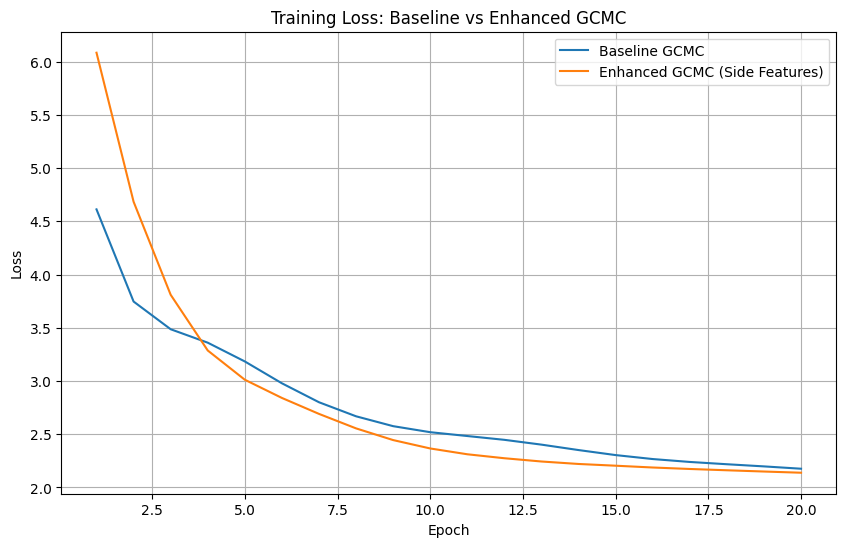

Enhanced GCMC reached Baseline's final loss at epoch 17 (saving 3 epochs)


In [33]:
# Cell 6: Plot convergence — Baseline vs Enhanced GCMC
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, BASELINE_EPOCHS + 1), baseline_gcmc_losses, label="Baseline GCMC")
plt.plot(range(1, ENHANCED_EPOCHS + 1), enhanced_gcmc_losses, label="Enhanced GCMC (Side Features)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss: Baseline vs Enhanced GCMC")
plt.legend()
plt.grid(True)
plt.show()

# Epoch at which Enhanced first beats Baseline's final loss
baseline_final_loss = baseline_gcmc_losses[-1]
beat_epoch = next((i+1 for i, l in enumerate(enhanced_gcmc_losses) if l <= baseline_final_loss), None)
if beat_epoch:
    print(f"Enhanced GCMC reached Baseline's final loss at epoch {beat_epoch} "
          f"(saving {BASELINE_EPOCHS - beat_epoch} epochs)")
else:
    print("Enhanced GCMC did not reach Baseline's final loss within the same epoch budget.")

In [34]:
# Cell 7: RMSE comparison — Baseline vs Enhanced GCMC
baseline_gcmc_model.eval()
enhanced_gcmc_model.eval()

rating_values_arr = torch.tensor(rating_values, dtype=torch.float32).to(device)

with torch.no_grad():
    probs_baseline = baseline_gcmc_model(edge_index_dict, test_users, test_movies)
preds_baseline = (probs_baseline * rating_values_arr).sum(dim=1).cpu().numpy()
baseline_rmse = np.sqrt(mean_squared_error(test_actual_ratings, preds_baseline))

with torch.no_grad():
    probs_enhanced = enhanced_gcmc_model(
        edge_index_dict, test_users, test_movies,
        user_side_features, movie_side_features
    )
preds_enhanced = (probs_enhanced * rating_values_arr).sum(dim=1).cpu().numpy()
enhanced_rmse = np.sqrt(mean_squared_error(test_actual_ratings, preds_enhanced))

print("===========================")
print("   GCMC Model RMSE Comparison")
print("===========================")
print(f"Baseline GCMC RMSE: {baseline_rmse:.4f}")
print(f"Enhanced GCMC RMSE: {enhanced_rmse:.4f}")
print("===========================")

   GCMC Model RMSE Comparison
Baseline GCMC RMSE: 1.0900
Enhanced GCMC RMSE: 1.1004


## Comparison: Baseline GCMC vs. Enhanced GCMC

### Training Loss Convergence
The training loss plot clearly shows how the **Enhanced GCMC** model, which incorporates user and movie side features, starts with a higher initial loss but quickly catches up to and surpasses the **Baseline GCMC** model.

- **Baseline GCMC final loss:** 2.1764
- **Enhanced GCMC final loss:** 2.1388

Notably, the Enhanced GCMC reached the Baseline's final loss at **epoch 17**, saving 3 epochs of training to achieve a similar or better loss value.

### RMSE Performance
Despite the better convergence in training loss, the RMSE on the test set for both models is very close:

- **Baseline GCMC RMSE:** 1.0900
- **Enhanced GCMC RMSE:** 1.1004

In this particular run, the Baseline GCMC achieved a slightly lower RMSE. This indicates that while side features helped the model converge faster during training, they did not translate into a significant improvement in generalization performance on this specific test set, and in fact, led to a marginally higher RMSE. This could be due to various factors like overfitting to the training data with the added features, or the features themselves not adding enough discriminatory power for the prediction task on the test set given the model's capacity.